In [ ]:
# Prepare dataset for environment
%pip install ucimlrepo

# Import packages to be used
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# This cell takes 9s to run.

Note: you may need to restart the kernel to use updated packages.


In [55]:
######## Power Consumption ##########
# Multivariate, Time Series; Regression, Clustering
  
# fetch dataset 
individual_household_electric_power_consumption = fetch_ucirepo(id=235) 

# print(type(individual_household_electric_power_consumption))

# df = pd.DataFrame.from_dict(individual_household_electric_power_consumption, orient='index')
# print(df)
  
# data (as pandas dataframes)
df = individual_household_electric_power_consumption.data.features 
print(df.head())

  # metadata 
# print(individual_household_electric_power_consumption.metadata) 

# Algorithms: k-means clustering, Principal component analysis

C:\Users\anher\AppData\Local\Temp/ipykernel_2224/3712865726.py:5: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types.Specify dtype option on import or set low_memory=False.
  individual_household_electric_power_consumption = fetch_ucirepo(id=235)


         Date      Time Global_active_power Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.840   
1  16/12/2006  17:25:00               5.360                 0.436  233.630   
2  16/12/2006  17:26:00               5.374                 0.498  233.290   
3  16/12/2006  17:27:00               5.388                 0.502  233.740   
4  16/12/2006  17:28:00               3.666                 0.528  235.680   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0           18.400          0.000          1.000            17.0  
1           23.000          0.000          1.000            16.0  
2           23.000          0.000          2.000            17.0  
3           23.000          0.000          1.000            17.0  
4           15.800          0.000          1.000            17.0  


In [103]:
##### Attempts to convert data types ######
#convertDic = {'Global_active_power' : float, 'Global_reactive_power' : float, 'Voltage' : float, 'Global_intensity' : float, 'Sub_metering_1' : float, 'Sub_metering_2' : float,'Sub_metering_3' : float }

# ndf = df.astype(convertDic)
# ndf = df.iloc[:, 2:].apply(pd.to_numeric)
#df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')
# print(df.dtypes)

#############################################

# Convert Date and Time column to datetime64 data type/
df ['Date'] = pd.to_datetime(df['Date'], errors='coerce')
#pd.to_timedelta(df['Time'], errors='coerce')
df['Time'] = pd.to_datetime(df['Time'], format="%H:%M:%S", errors='coerce')

# Convert rest of columns to float64 data type.
for column in df.columns[2:]:
    df[column] = pd.to_numeric(df[column], errors='coerce')
print(df.dtypes)


Date                     datetime64[ns]
Time                     datetime64[ns]
Global_active_power             float64
Global_reactive_power           float64
Voltage                         float64
Global_intensity                float64
Sub_metering_1                  float64
Sub_metering_2                  float64
Sub_metering_3                  float64
dtype: object


0         2006-12-16
1         2006-12-16
2         2006-12-16
3         2006-12-16
4         2006-12-16
             ...    
2075254   2010-11-26
2075255   2010-11-26
2075256   2010-11-26
2075257   2010-11-26
2075258   2010-11-26
Name: Date, Length: 2075259, dtype: datetime64[ns]
0          4.216
1          5.360
2          5.374
3          5.388
4          3.666
           ...  
2075254    0.946
2075255    0.944
2075256    0.938
2075257    0.934
2075258    0.932
Name: Global_active_power, Length: 2075259, dtype: float64


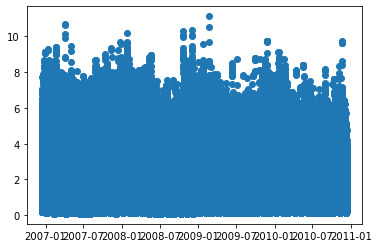

In [105]:
# print(df.columns)
# print(df[:]) rows
x = df.Date
print(x)
y = df.Global_active_power
print(y)

plt.scatter(x,y)
plt.show()